In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Data/cleaned_data.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
print(f'Total Customer:{df.shape[0]}')

Total Customer:7032


Total Customer:7032


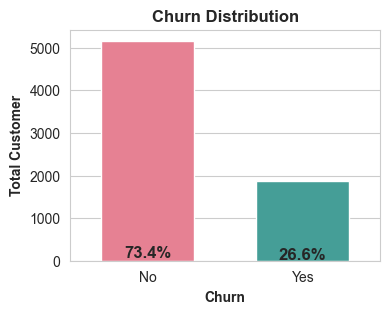

In [ ]:
churn_percent = df['Churn'].value_counts(normalize=True)*100

plt.figure(figsize=(4,3))
sns.set_style("whitegrid")
sns.countplot(
    df, x='Churn',
    palette="husl",
    width=0.6,
    legend="full"
)
plt.title("Churn Distribution", weight='bold')
plt.xlabel('Churn', weight='bold')
plt.ylabel('Total Customer', weight='bold')
for i, v in enumerate(churn_percent.values):
    plt.text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)
plt.show()


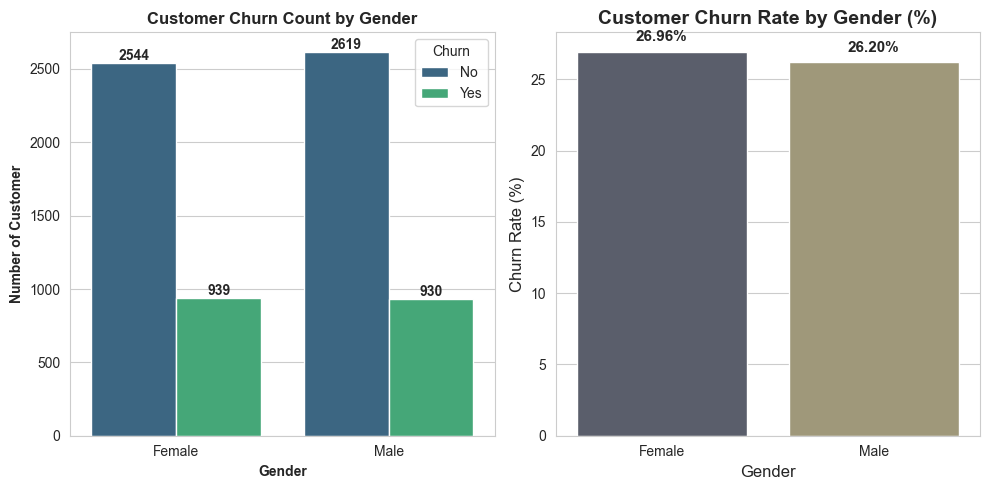

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.countplot(
    data=df,
    x='gender',
    hue='Churn',
    palette='viridis',
    ax= axes[0]
)
axes[0].set_title("Customer Churn Count by Gender", weight='bold')
axes[0].set_xlabel("Gender", weight='bold')
axes[0].set_ylabel("Number of Customer", weight='bold')

for container in axes[0].containers:
    axes[0].bar_label(container, weight='bold')


gender_churn_rate = pd.crosstab(df['gender'], df['Churn'], normalize='index')*100
gender_churn_rate_yes = gender_churn_rate['Yes'].sort_values(ascending=False)
sns.barplot(
    x = gender_churn_rate_yes.index,
    y = gender_churn_rate_yes.values,
    palette='cividis',
    ax=axes[1]
)
axes[1].set_title("Customer Churn Rate by Gender (%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Gender", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)", fontsize=12)


for i, value in enumerate(gender_churn_rate_yes.values):
    axes[1].text(i, value + 0.5, f"{value:.2f}%", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()